# NB2 — Human-AI Interaction Analysis

**Purpose**: Dissect how users interact with AI predictions.  
Covers over-reliance, skepticism, agreement rates, confidence calibration, symptom analysis, and reversion behavior.

---

In [1]:
# ── Imports & Setup ──
import sys, os, warnings
import numpy as np
import pandas as pd
from scipy import stats
import pingouin as pg

warnings.filterwarnings('ignore', category=FutureWarning)
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from helpers import (
    load_and_clean, derive_variables, get_participant_summary,
    get_completers, setup_plotting, COLORS, CONDITION_PALETTE, add_significance
)

plt, sns = setup_plotting()

df = load_and_clean()
df = derive_variables(df)
ai = df[df['ai_shown'] == True].copy()
ps = get_participant_summary(df)

print(f'AI trials: {len(ai)}, Participants with AI data: {ai["participant_id"].nunique()}')

═══════════════════════════════════════════════════════
  RADIOLOGIST GROUND TRUTH APPLIED
  File: Radiologist_Ground_Truth.csv
═══════════════════════════════════════════════════════
  Amb images (KL1):  23 images, 2737 trials
  Action taken:      KEEP_AS_NEGATIVE
  Rows:              5950 → 5950
  Label flips:       1666 trials (14 images)
  Flipped images:    ['4.png', '5.png', '6.png', '10.png', '17.png', '20.png', '23.png', '24.png', '33.png', '36.png', '37.png', '41.png', '44.png', '49.png']
  New class balance: 0=3451  1=2499
═══════════════════════════════════════════════════════
AI trials: 3050, Participants with AI data: 61


## 1. Agreement, Over-reliance & Skepticism Rates

In [2]:
# Overall rates
print('=== Human-AI Interaction Rates ===')
print(f'Agreement rate (final == ai_prediction):  {ai["agreed_with_ai"].mean():.3f}')
print(f'Over-reliance (agree with WRONG AI):      {ai["over_reliance"].mean():.3f}')
print(f'Skepticism (reject CORRECT AI):           {ai["skepticism"].mean():.3f}')
print()

# Conditional rates
ai_correct_trials = ai[ai['ai_correct'] == 1]
ai_wrong_trials = ai[ai['ai_correct'] == 0]
print(f'When AI is CORRECT (n={len(ai_correct_trials)}):')
print(f'  Followed AI: {ai_correct_trials["agreed_with_ai"].mean():.3f}')
print(f'  Skepticism:  {ai_correct_trials["skepticism"].mean():.3f}')
print(f'When AI is WRONG (n={len(ai_wrong_trials)}):')
print(f'  Followed AI (over-reliance): {ai_wrong_trials["agreed_with_ai"].mean():.3f}')
print(f'  Rejected AI:                 {1 - ai_wrong_trials["agreed_with_ai"].mean():.3f}')

=== Human-AI Interaction Rates ===
Agreement rate (final == ai_prediction):  0.660
Over-reliance (agree with WRONG AI):      0.138
Skepticism (reject CORRECT AI):           0.178

When AI is CORRECT (n=2135):
  Followed AI: 0.746
  Skepticism:  0.254
When AI is WRONG (n=915):
  Followed AI (over-reliance): 0.461
  Rejected AI:                 0.539


In [3]:
# Human × AI × Ground Truth confusion analysis
# 2×2×2 breakdown
breakdown = ai.groupby(['ai_correct', 'agreed_with_ai']).agg(
    count=('user_correct', 'size'),
    user_accuracy=('user_correct', 'mean')
).reset_index()

breakdown['ai_correct'] = breakdown['ai_correct'].map({1.0: 'AI Correct', 0.0: 'AI Wrong'})
breakdown['agreed_with_ai'] = breakdown['agreed_with_ai'].map({1.0: 'Followed AI', 0.0: 'Rejected AI'})
breakdown['pct'] = (breakdown['count'] / len(ai) * 100).round(1)

print('=== Outcome Matrix ===')
display(breakdown.rename(columns={'pct': '% of trials', 'user_accuracy': 'user_acc'}).round(3))

=== Outcome Matrix ===


,ai_correct,agreed_with_ai,count,user_acc,% of trials
0,AI Wrong,Rejected AI,493,1.0,16.2
1,AI Wrong,Followed AI,422,0.0,13.8
2,AI Correct,Rejected AI,543,0.0,17.8
3,AI Correct,Followed AI,1592,1.0,52.2


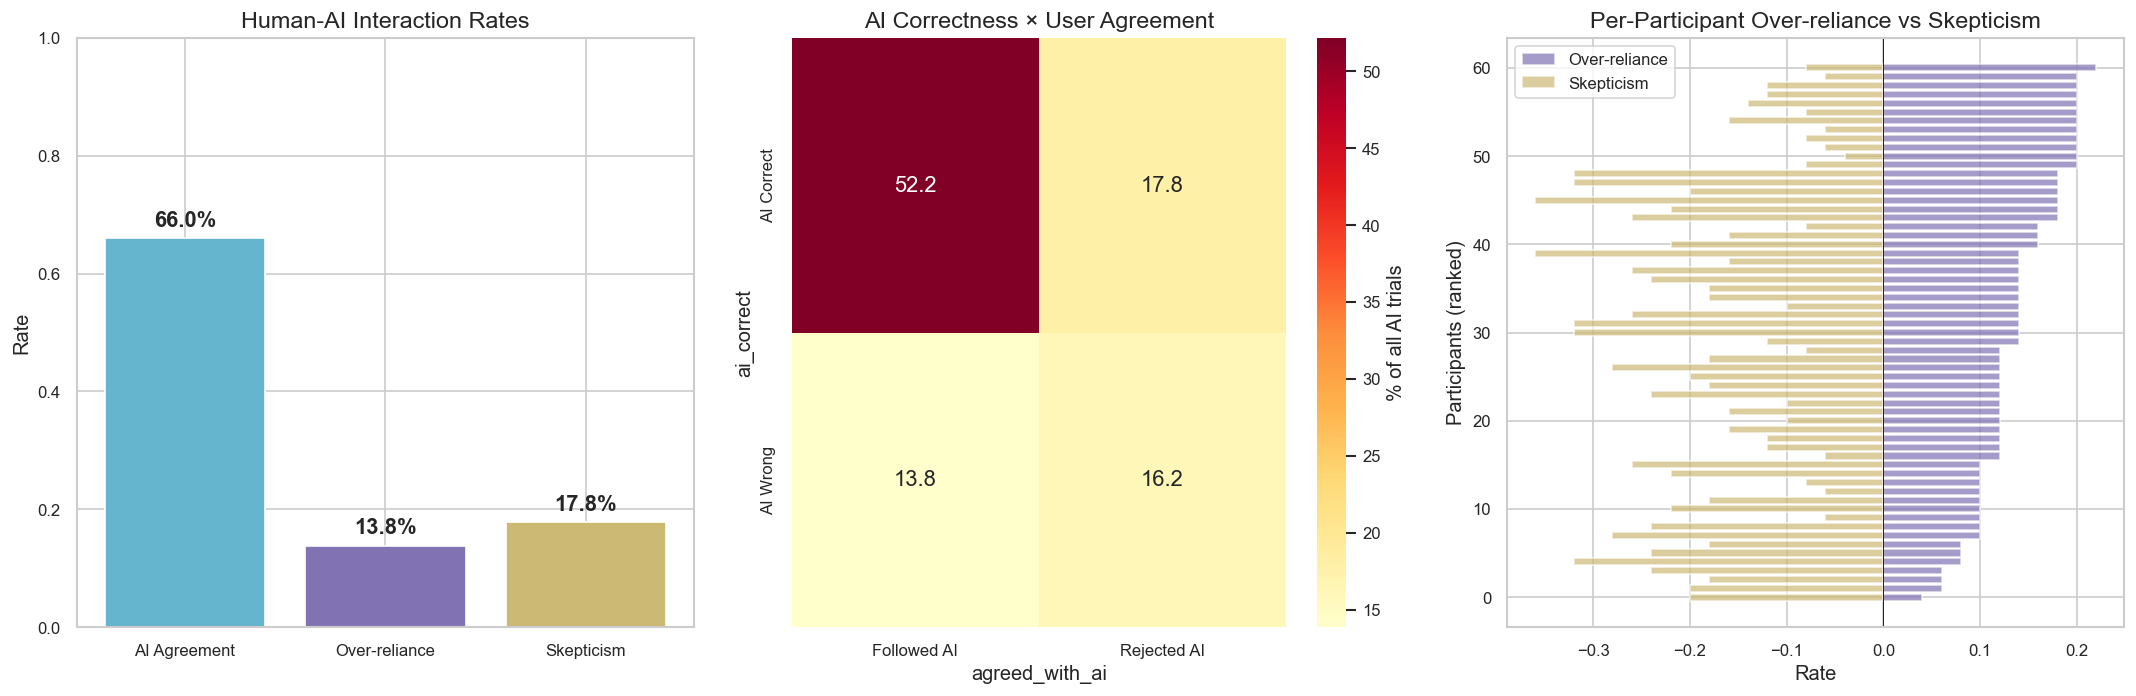

In [4]:
# Visualization: over-reliance and skepticism
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Overall rates bar chart
rates = pd.Series({
    'AI Agreement': ai['agreed_with_ai'].mean(),
    'Over-reliance': ai['over_reliance'].mean(),
    'Skepticism': ai['skepticism'].mean(),
})
bars = axes[0].bar(rates.index, rates.values, 
                  color=[COLORS['neutral'], COLORS['over_reliance'], COLORS['skepticism']])
axes[0].set_ylim(0, 1)
axes[0].set_title('Human-AI Interaction Rates')
axes[0].set_ylabel('Rate')
for bar, val in zip(bars, rates.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.02, f'{val:.1%}', 
               ha='center', fontweight='bold')

# Heatmap: 2×2 matrix
matrix = pd.crosstab(
    ai['ai_correct'].map({1.0: 'AI Correct', 0.0: 'AI Wrong'}),
    ai['agreed_with_ai'].map({1.0: 'Followed AI', 0.0: 'Rejected AI'}),
    normalize='all'
) * 100
sns.heatmap(matrix, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
           cbar_kws={'label': '% of all AI trials'})
axes[1].set_title('AI Correctness × User Agreement')

# Per-participant rates
ps_ai = ps[ps['over_reliance_rate'].notna()].sort_values('over_reliance_rate')
x = np.arange(len(ps_ai))
axes[2].barh(x, ps_ai['over_reliance_rate'], color=COLORS['over_reliance'], 
           alpha=0.7, label='Over-reliance')
axes[2].barh(x, -ps_ai['skepticism_rate'], color=COLORS['skepticism'], 
           alpha=0.7, label='Skepticism')
axes[2].axvline(x=0, color='black', linewidth=0.5)
axes[2].set_title('Per-Participant Over-reliance vs Skepticism')
axes[2].set_xlabel('Rate')
axes[2].set_ylabel('Participants (ranked)')
axes[2].legend()

plt.tight_layout()
plt.show()

## 2. AI Confidence Effect

Does higher `ai_confidence` lead to more agreement and higher over-reliance?

In [5]:
# Bin AI confidence and analyze agreement
ai['ai_conf_quartile'] = pd.qcut(ai['ai_confidence'], q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

ai_conf_analysis = ai.groupby('ai_conf_quartile').agg(
    agreement_rate=('agreed_with_ai', 'mean'),
    over_reliance_rate=('over_reliance', 'mean'),
    skepticism_rate=('skepticism', 'mean'),
    user_accuracy=('user_correct', 'mean'),
    ai_accuracy=('ai_correct', 'mean'),
    n_trials=('user_correct', 'count'),
    mean_conf=('ai_confidence', 'mean')
).round(3)

print('=== Agreement & Accuracy by AI Confidence Quartile ===')
display(ai_conf_analysis)

# Correlation
r_agree, p_agree = stats.spearmanr(ai['ai_confidence'], ai['agreed_with_ai'])
print(f'\nSpearman: AI confidence → Agreement: r={r_agree:.3f}, p={p_agree:.4f}')

=== Agreement & Accuracy by AI Confidence Quartile ===


,agreement_rate,over_reliance_rate,skepticism_rate,user_accuracy,ai_accuracy,n_trials,mean_conf
ai_conf_quartile,,,,,,,
Q1 (low),0.585,0.148,0.255,0.598,0.692,793,0.196
Q2,0.541,0.154,0.197,0.649,0.583,732,0.548
Q3,0.646,0.142,0.189,0.668,0.692,793,0.781
Q4 (high),0.877,0.108,0.064,0.828,0.833,732,0.946



Spearman: AI confidence → Agreement: r=0.212, p=0.0000


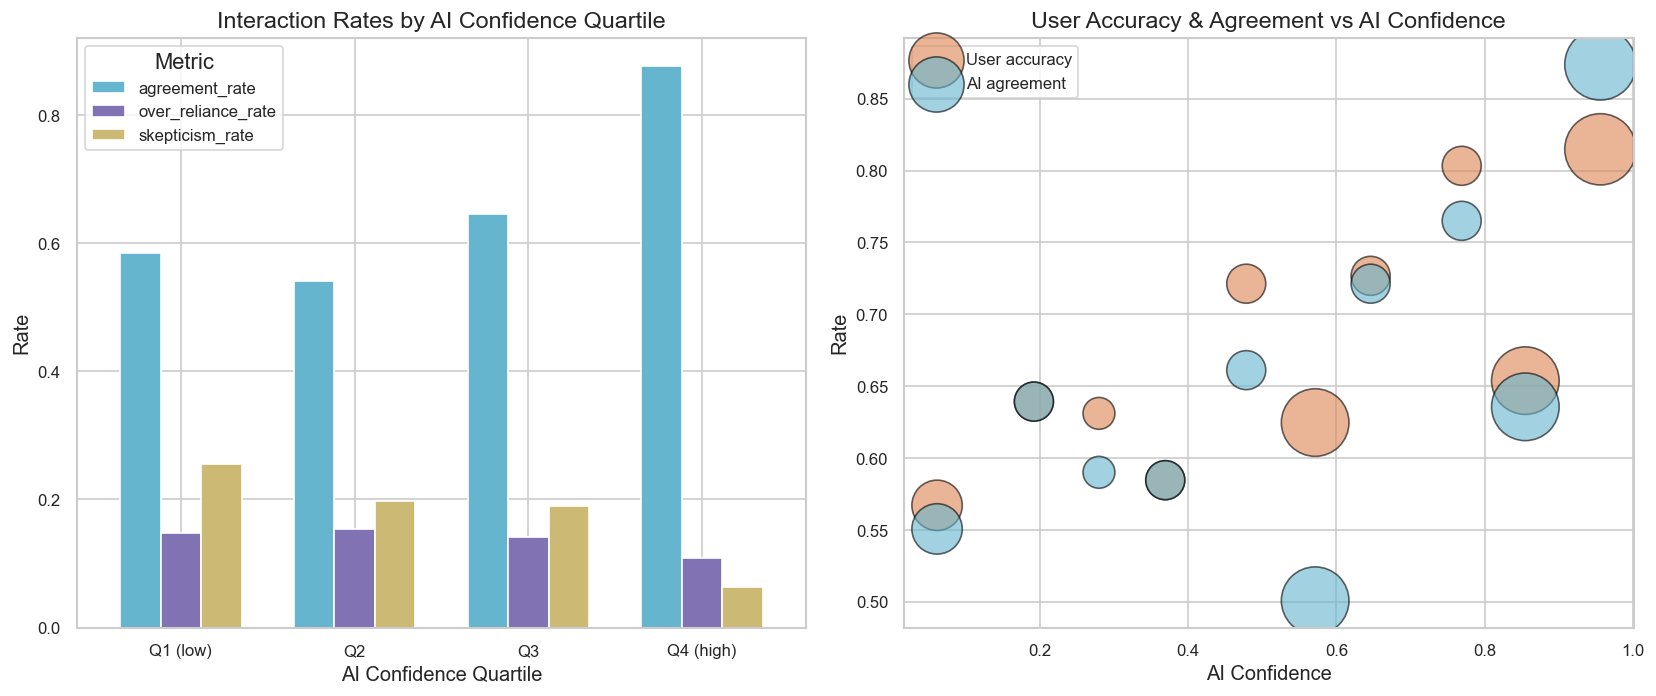

In [6]:
# Visualization: AI confidence effect
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Agreement rate by AI confidence quartile
ai_conf_analysis[['agreement_rate', 'over_reliance_rate', 'skepticism_rate']].plot(
    kind='bar', ax=axes[0], 
    color=[COLORS['neutral'], COLORS['over_reliance'], COLORS['skepticism']],
    width=0.7
)
axes[0].set_title('Interaction Rates by AI Confidence Quartile')
axes[0].set_ylabel('Rate')
axes[0].set_xlabel('AI Confidence Quartile')
axes[0].legend(title='Metric')
axes[0].tick_params(axis='x', rotation=0)

# Scatter: AI confidence vs user accuracy (trial-level with binning)
ai['ai_conf_bin'] = pd.cut(ai['ai_confidence'], bins=10)
binned = ai.groupby('ai_conf_bin').agg(
    user_acc=('user_correct', 'mean'),
    agreement=('agreed_with_ai', 'mean'),
    n=('user_correct', 'count'),
    mid_conf=('ai_confidence', 'mean')
)
valid = binned[binned['n'] >= 10]

axes[1].scatter(valid['mid_conf'], valid['user_acc'], s=valid['n']*3, 
              color=COLORS['ai'], alpha=0.6, edgecolor='black', label='User accuracy')
axes[1].scatter(valid['mid_conf'], valid['agreement'], s=valid['n']*3, 
              color=COLORS['neutral'], alpha=0.6, edgecolor='black', label='AI agreement')
axes[1].set_xlabel('AI Confidence')
axes[1].set_ylabel('Rate')
axes[1].set_title('User Accuracy & Agreement vs AI Confidence')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Confidence Calibration

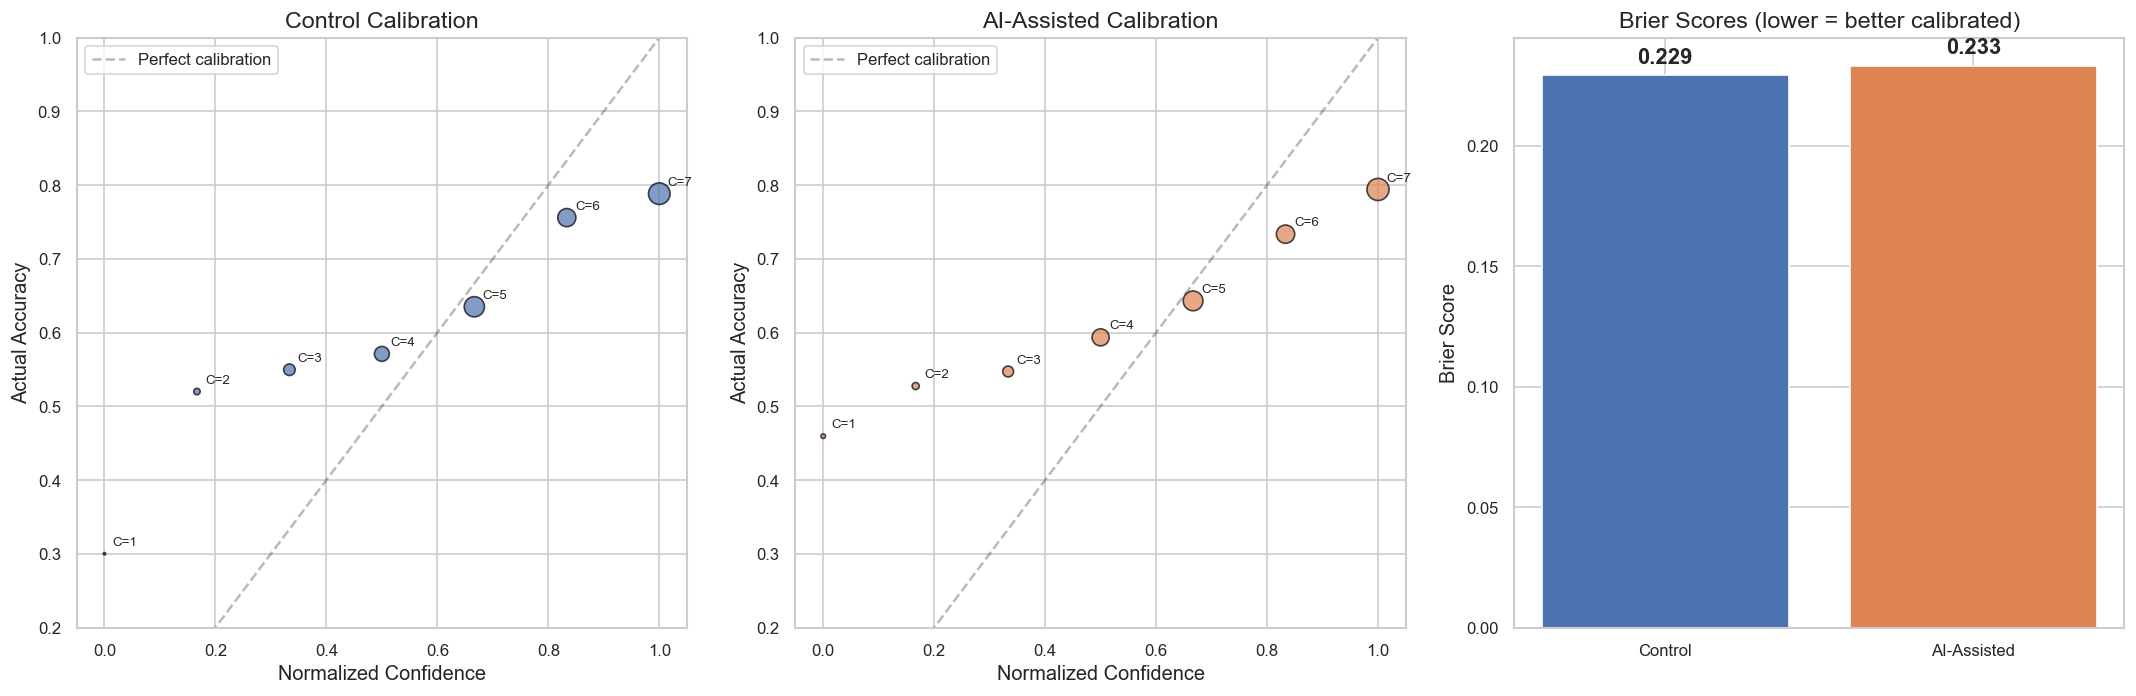

In [7]:
# Calibration: user confidence vs actual accuracy
# For Control: use 'confidence'
# For AI: use 'final_confidence'

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (cond_name, cond_data) in enumerate([
    ('Control', df[df['condition'] == 'Control']),
    ('AI-Assisted', df[df['condition'] == 'AI-Assisted'])
]):
    cal = cond_data.groupby('user_confidence').agg(
        accuracy=('user_correct', 'mean'),
        count=('user_correct', 'count')
    )
    
    ax = axes[idx]
    # Normalize confidence to [0,1] for calibration comparison
    norm_conf = (cal.index - 1) / 6  # 1-7 → 0-1
    ax.scatter(norm_conf, cal['accuracy'], s=cal['count']/5, 
             color=COLORS['control'] if cond_name == 'Control' else COLORS['ai'],
             alpha=0.7, edgecolor='black')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect calibration')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0.2, 1.0)
    ax.set_xlabel('Normalized Confidence')
    ax.set_ylabel('Actual Accuracy')
    ax.set_title(f'{cond_name} Calibration')
    ax.legend()
    
    # Label each point with the confidence level
    for ci, (conf, row) in enumerate(cal.iterrows()):
        ax.annotate(f'C={int(conf)}', (norm_conf[ci], row['accuracy']),
                   textcoords='offset points', xytext=(5, 5), fontsize=8)

# Brier scores
ctrl_data = df[df['condition'] == 'Control'].copy()
ai_data = df[df['condition'] == 'AI-Assisted'].copy()

# Normalize confidence to probability [0, 1]
ctrl_data['conf_prob'] = (ctrl_data['user_confidence'] - 1) / 6
ai_data['conf_prob'] = (ai_data['user_confidence'] - 1) / 6

brier_ctrl = ((ctrl_data['conf_prob'] - ctrl_data['user_correct'])**2).mean()
brier_ai = ((ai_data['conf_prob'] - ai_data['user_correct'])**2).mean()

brier_df = pd.DataFrame({
    'Condition': ['Control', 'AI-Assisted'],
    'Brier Score': [brier_ctrl, brier_ai]
})
axes[2].bar(brier_df['Condition'], brier_df['Brier Score'],
           color=[COLORS['control'], COLORS['ai']])
axes[2].set_title('Brier Scores (lower = better calibrated)')
axes[2].set_ylabel('Brier Score')
for i, v in enumerate(brier_df['Brier Score']):
    axes[2].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Confidence Shift Analysis

How does seeing AI prediction change user confidence?

In [8]:
# Confidence shift: final_confidence - initial_confidence (AI trials only)
print('=== Confidence Shift in AI Trials ===')
print(f'Mean shift: {ai["confidence_shift"].mean():.3f}')
print(f'Shift when decision CHANGED: {ai[ai["decision_changed"]==1]["confidence_shift"].mean():.3f}')
print(f'Shift when decision KEPT:    {ai[ai["decision_changed"]==0]["confidence_shift"].mean():.3f}')
print()

# Shift by whether user agrees with AI
for agree_label, agree_val in [('Agreed with AI', 1.0), ('Disagreed with AI', 0.0)]:
    subset = ai[ai['agreed_with_ai'] == agree_val]
    print(f'{agree_label}: mean shift = {subset["confidence_shift"].mean():.3f} (n={len(subset)})')

# Shift by AI correctness
print()
for correct_label, correct_val in [('AI was correct', 1.0), ('AI was wrong', 0.0)]:
    subset = ai[ai['ai_correct'] == correct_val]
    print(f'{correct_label}: mean shift = {subset["confidence_shift"].mean():.3f} (n={len(subset)})')

=== Confidence Shift in AI Trials ===
Mean shift: 0.219
Shift when decision CHANGED: 0.041
Shift when decision KEPT:    0.238

Agreed with AI: mean shift = 0.484 (n=2014)
Disagreed with AI: mean shift = -0.297 (n=1036)

AI was correct: mean shift = 0.322 (n=2135)
AI was wrong: mean shift = -0.022 (n=915)


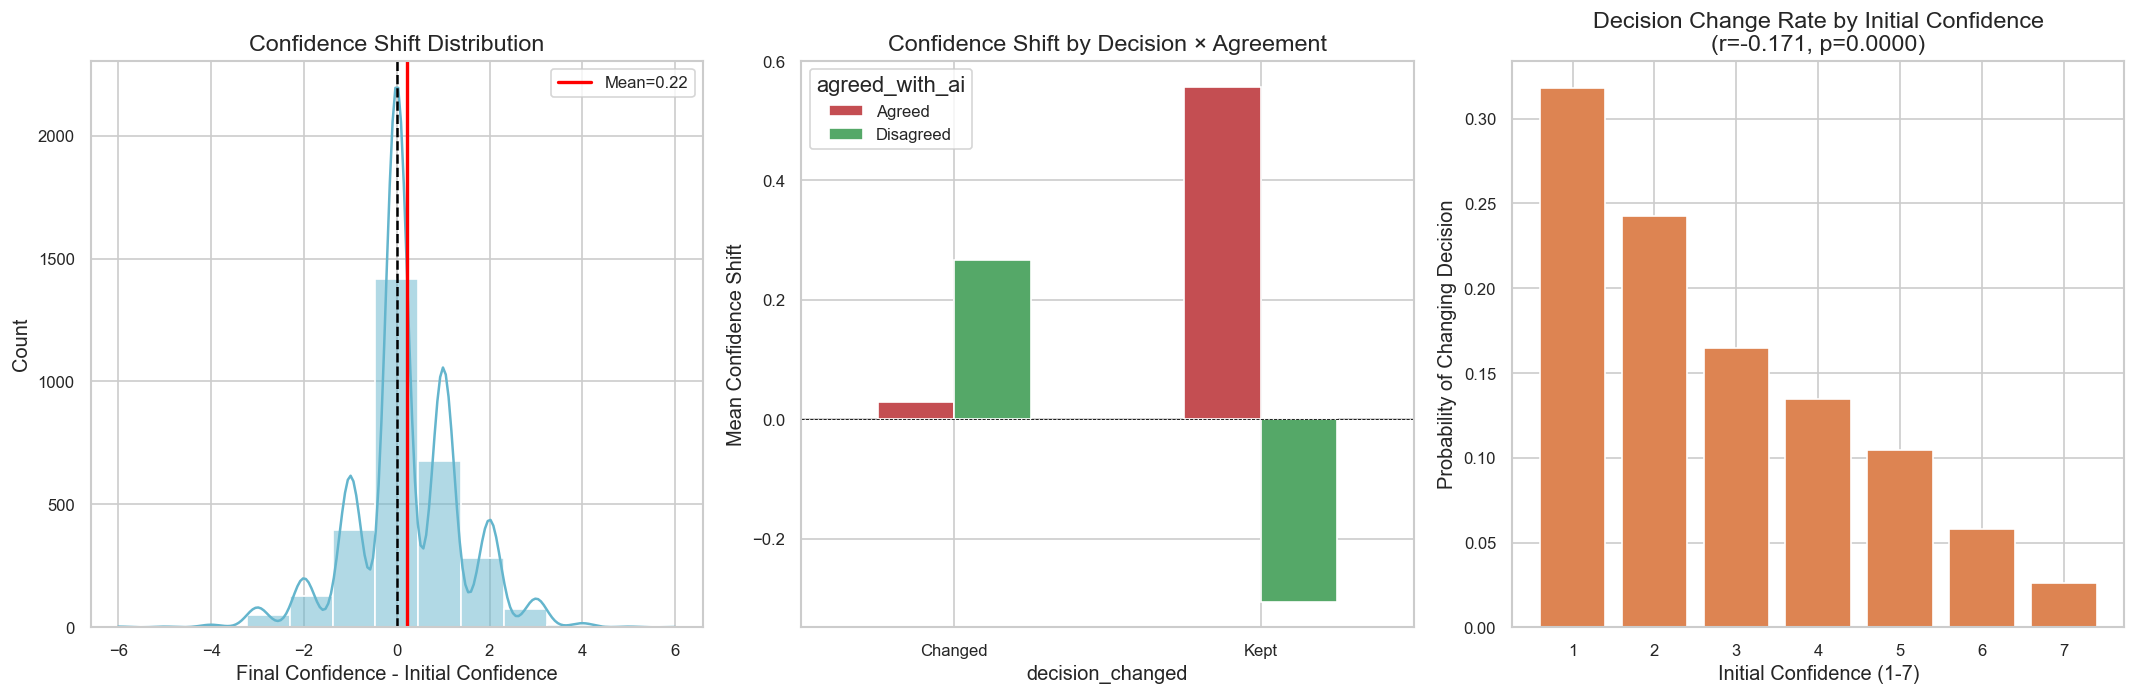

In [9]:
# Visualization: confidence shifts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Distribution of confidence shift
sns.histplot(ai['confidence_shift'].dropna(), bins=13, ax=axes[0], 
            color=COLORS['neutral'], kde=True)
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].axvline(x=ai['confidence_shift'].mean(), color='red', linewidth=2,
              label=f'Mean={ai["confidence_shift"].mean():.2f}')
axes[0].set_title('Confidence Shift Distribution')
axes[0].set_xlabel('Final Confidence - Initial Confidence')
axes[0].legend()

# Shift by decision change × agreement
shift_matrix = ai.groupby(
    [ai['decision_changed'].map({1.0: 'Changed', 0.0: 'Kept'}),
     ai['agreed_with_ai'].map({1.0: 'Agreed', 0.0: 'Disagreed'})]
)['confidence_shift'].mean().unstack()
shift_matrix.plot(kind='bar', ax=axes[1], color=[COLORS['incorrect'], COLORS['correct']])
axes[1].set_title('Confidence Shift by Decision × Agreement')
axes[1].set_ylabel('Mean Confidence Shift')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[1].tick_params(axis='x', rotation=0)

# Initial confidence → probability of changing decision
change_by_conf = ai.groupby('initial_confidence')['decision_changed'].mean()
axes[2].bar(change_by_conf.index, change_by_conf.values, color=COLORS['ai'])
axes[2].set_title('Decision Change Rate by Initial Confidence')
axes[2].set_xlabel('Initial Confidence (1-7)')
axes[2].set_ylabel('Probability of Changing Decision')

r_conf_change, p_conf_change = stats.spearmanr(
    ai['initial_confidence'].dropna(), ai['decision_changed'].dropna()
)
axes[2].set_title(f'Decision Change Rate by Initial Confidence\n(r={r_conf_change:.3f}, p={p_conf_change:.4f})')

plt.tight_layout()
plt.show()

## 5a. Symptom Category Analysis

Do users who report "uncertain" (bizonytalan) show different AI interaction patterns?

In [10]:
# Symptom analysis (AI trials only, where symptom data exists)
symptom_data = ai[ai['symptom1_en'].notna()].copy()

print('=== Symptom Category Analysis ===')
symptom_analysis = symptom_data.groupby('symptom1_en').agg(
    n_trials=('user_correct', 'count'),
    user_accuracy=('user_correct', 'mean'),
    agreement_rate=('agreed_with_ai', 'mean'),
    over_reliance=('over_reliance', 'mean'),
    skepticism=('skepticism', 'mean'),
    decision_changed=('decision_changed', 'mean'),
    mean_confidence=('user_confidence', 'mean'),
).round(3)

display(symptom_analysis)

# Chi-square: symptom category × accuracy
ct = pd.crosstab(symptom_data['symptom1_en'], symptom_data['user_correct'])
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
print(f'\nChi-square (symptom1 × accuracy): χ²={chi2:.3f}, p={p_chi:.4f}')

=== Symptom Category Analysis ===


,n_trials,user_accuracy,agreement_rate,over_reliance,skepticism,decision_changed,mean_confidence
symptom1_en,,,,,,,
none,1514,0.687,0.646,0.152,0.161,0.100,5.266
symptom,1076,0.694,0.686,0.102,0.204,0.072,5.699
uncertain,460,0.648,0.648,0.178,0.174,0.141,4.650



Chi-square (symptom1 × accuracy): χ²=3.362, p=0.1862


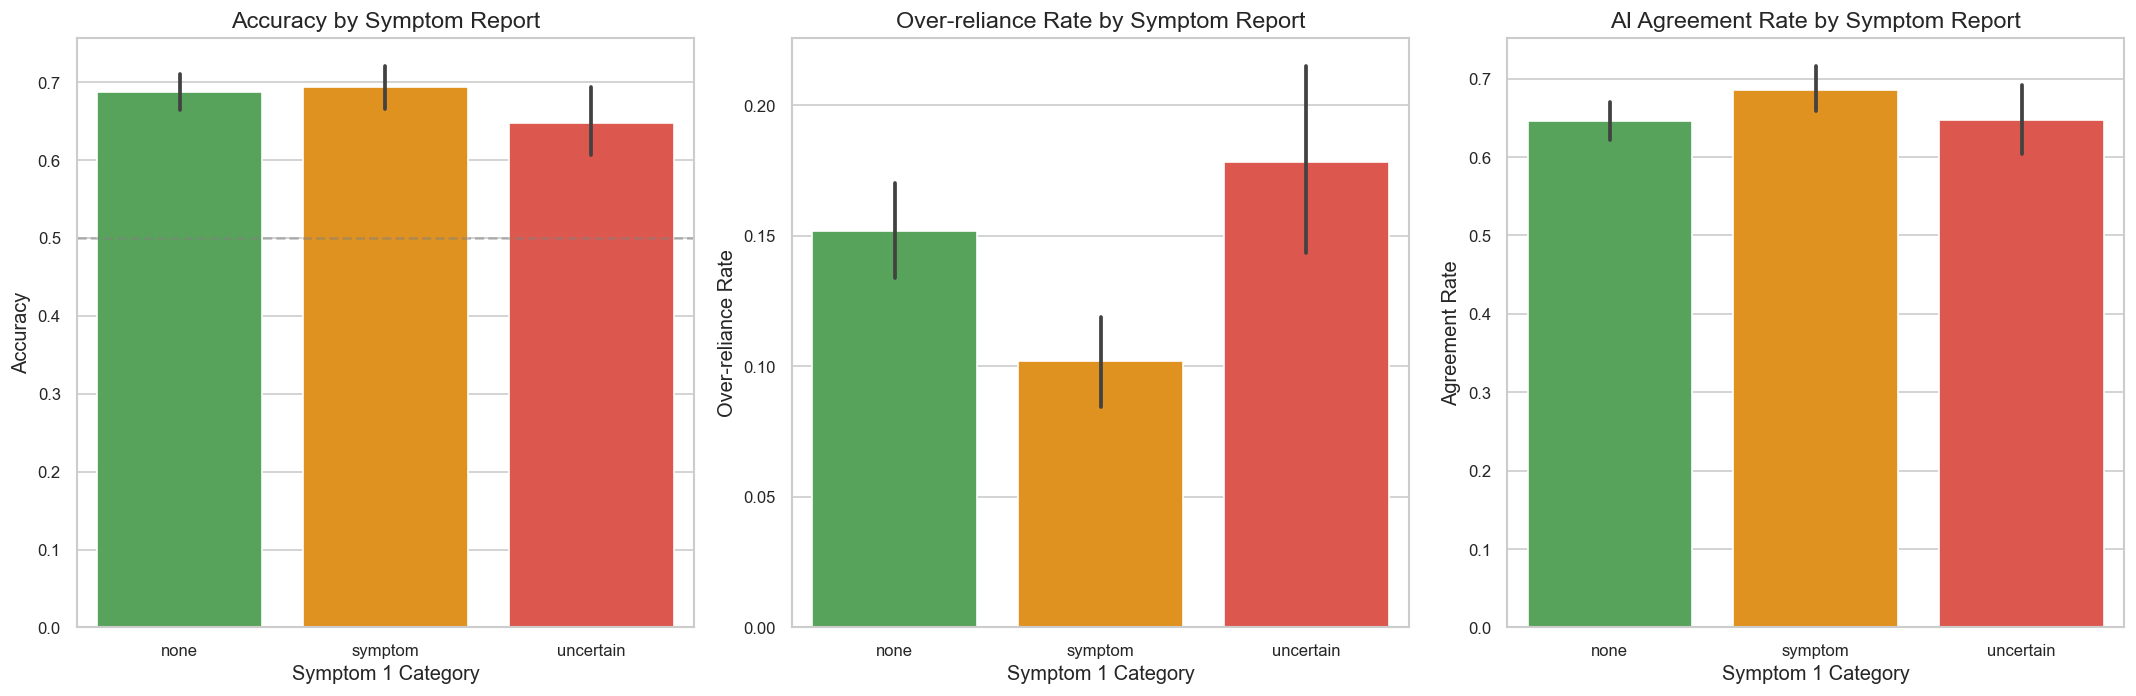

In [11]:
# Visualization: symptom categories
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

order = ['none', 'symptom', 'uncertain']
palette = ['#4CAF50', '#FF9800', '#F44336']

# Accuracy by symptom
sns.barplot(data=symptom_data, x='symptom1_en', y='user_correct', order=order,
           ax=axes[0], palette=palette, ci=95)
axes[0].set_title('Accuracy by Symptom Report')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Symptom 1 Category')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Over-reliance by symptom
sns.barplot(data=symptom_data, x='symptom1_en', y='over_reliance', order=order,
           ax=axes[1], palette=palette, ci=95)
axes[1].set_title('Over-reliance Rate by Symptom Report')
axes[1].set_ylabel('Over-reliance Rate')
axes[1].set_xlabel('Symptom 1 Category')

# Agreement rate by symptom
sns.barplot(data=symptom_data, x='symptom1_en', y='agreed_with_ai', order=order,
           ax=axes[2], palette=palette, ci=95)
axes[2].set_title('AI Agreement Rate by Symptom Report')
axes[2].set_ylabel('Agreement Rate')
axes[2].set_xlabel('Symptom 1 Category')

plt.tight_layout()
plt.show()

## 5b. Metacognition Check: Do "Uncertain" Reports Track Image Difficulty?

§5b. Metacognition: Do Uncertain Reports Track Image Difficulty?
  Spearman r(uncertain_rate ~ human_accuracy) = -0.099, p = 0.4938

── Mean Uncertainty Rate: Ambiguous vs Clear Images ──
                   mean    std  count
difficulty_group                     
Ambiguous (KL1)   0.158  0.035     23
Ambiguous (KL2)   0.182  0.052     13
Clear (KL0)       0.115  0.056      6
Clear (KL3)       0.117  0.053      7
Clear (KL4)       0.049    NaN      1

── Trial-Level: Uncertain vs Non-Uncertain Reporters ──
  Uncertain trials: 460 | Other: 2590


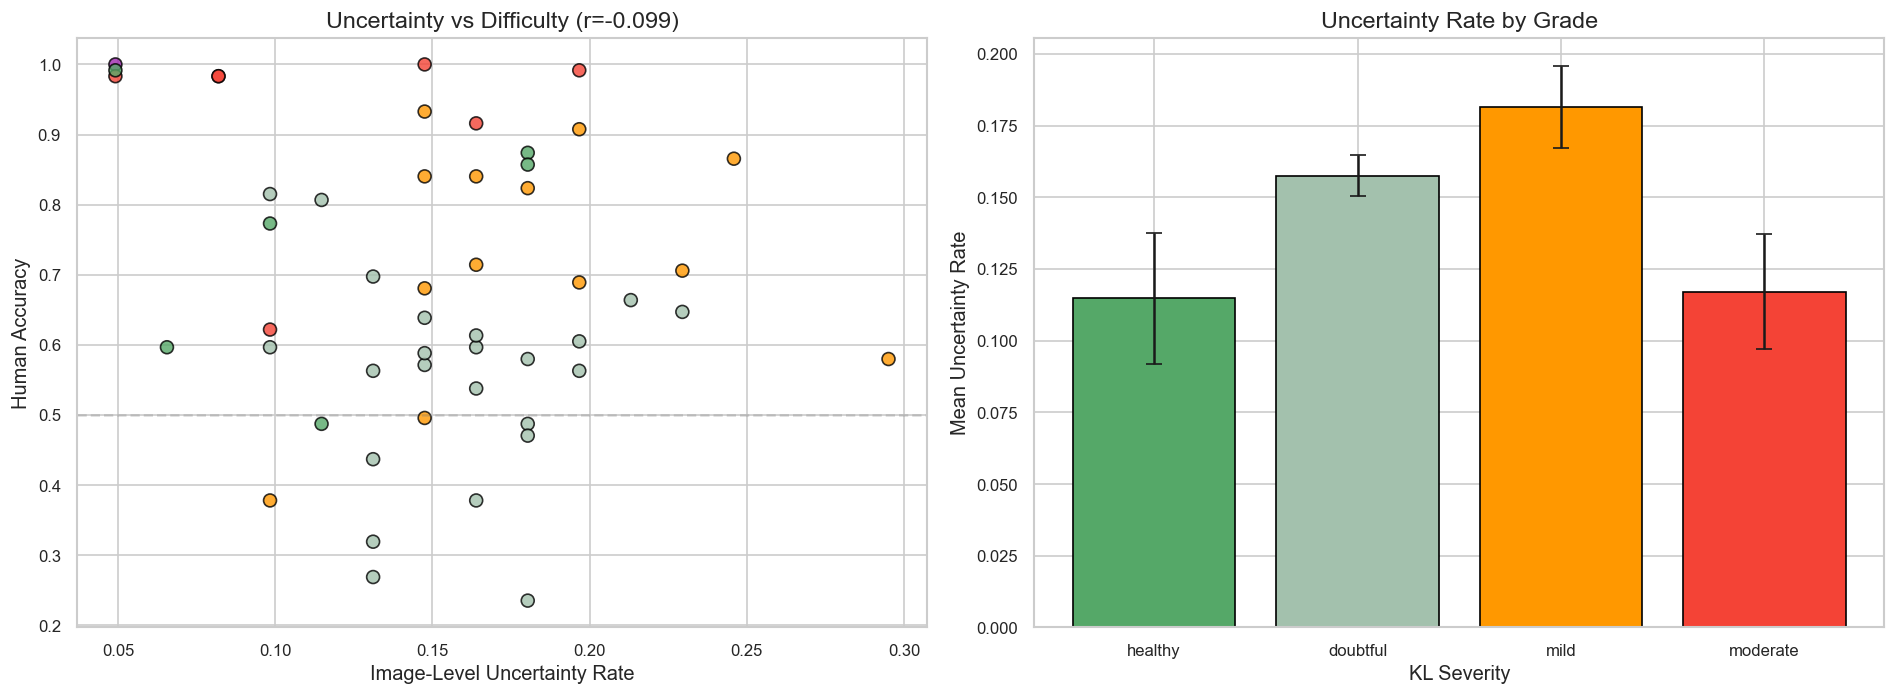

In [12]:
# ── Per-image uncertainty rate (AI trials only, where symptoms exist) ──
ai_df = df[df['ai_shown'] == True].copy()
ai_with_symptom = ai_df[ai_df['symptom1_en'].notna()].copy()

image_uncertainty = (
    ai_with_symptom
    .groupby('trial_original_image_name')
    .agg(
        uncertain_rate=('symptom1_en', lambda x: (x == 'uncertain').mean()),
        none_rate     =('symptom1_en', lambda x: (x == 'none').mean()),
        symptom_rate  =('symptom1_en', lambda x: (x == 'symptom').mean()),
        n_reports     =('symptom1_en', 'count'),
    )
    .reset_index()
)

# Define image-level performance (img_stats) and join with difficulty
img_stats = df.groupby('trial_original_image_name').agg(
    human_accuracy=('user_correct', 'mean'),
    kl_severity   =('kl_severity', 'first'),
).reset_index()

# Define image-level AI performance (img_ai)
img_ai = ai_df.groupby('trial_original_image_name').agg(
    ai_accuracy=('ai_correct', 'mean')
).reset_index()

# Final merge for image-level metrics
img_merged = image_uncertainty.merge(img_stats, on='trial_original_image_name')
img_merged = img_merged.merge(img_ai, on='trial_original_image_name', how='left')

# Grouping logic: Doubtful/Mild are "Ambiguous", others are "Clear"
img_merged['difficulty_group'] = img_merged['kl_severity'].map({
    'healthy': 'Clear (KL0)', 
    'doubtful': 'Ambiguous (KL1)', 
    'mild': 'Ambiguous (KL2)',
    'moderate': 'Clear (KL3)', 
    'severe': 'Clear (KL4)'
})

# ── Core correlation ──
from scipy.stats import spearmanr, kruskal
r_unc, p_unc = spearmanr(img_merged['uncertain_rate'], img_merged['human_accuracy'])

print("§5b. Metacognition: Do Uncertain Reports Track Image Difficulty?")
print(f"  Spearman r(uncertain_rate ~ human_accuracy) = {r_unc:.3f}, p = {p_unc:.4f}")
print()

# ── By difficulty group ──
print("── Mean Uncertainty Rate: Ambiguous vs Clear Images ──")
print(img_merged.groupby('difficulty_group')['uncertain_rate']
      .agg(['mean','std','count']).round(3))
print()

# ── Trial-Level: Uncertain vs Non-Uncertain Reporters ──
print("── Trial-Level: Uncertain vs Non-Uncertain Reporters ──")
uncertain_trials = ai_with_symptom[ai_with_symptom['symptom1_en'] == 'uncertain']
non_uncertain    = ai_with_symptom[ai_with_symptom['symptom1_en'] != 'uncertain']
print(f"  Uncertain trials: {len(uncertain_trials)} | Other: {len(non_uncertain)}")

# ── Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: uncertainty rate vs human accuracy
kl_color_map = {
    'healthy': COLORS['correct'], 'doubtful': '#A3C1AD', 'mild': '#FF9800', 
    'moderate': '#F44336', 'severe': '#9C27B0'
}
dot_colors = img_merged['kl_severity'].map(kl_color_map)

axes[0].scatter(img_merged['uncertain_rate'], img_merged['human_accuracy'],
                c=dot_colors, edgecolors='black', s=60, alpha=0.8)
axes[0].set_xlabel('Image-Level Uncertainty Rate')
axes[0].set_ylabel('Human Accuracy')
axes[0].set_title(f'Uncertainty vs Difficulty (r={r_unc:.3f})')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)

# Plot 2: Uncertainty rate by KL severity
kl_order = ['healthy', 'doubtful', 'mild', 'moderate', 'severe']
kl_unc = (img_merged.groupby('kl_severity')['uncertain_rate']
          .agg(['mean','sem']).reindex(kl_order).dropna())
axes[1].bar(kl_unc.index, kl_unc['mean'], yerr=kl_unc['sem'],
            color=[kl_color_map[k] for k in kl_unc.index],
            capsize=5, edgecolor='black')
axes[1].set_xlabel('KL Severity')
axes[1].set_ylabel('Mean Uncertainty Rate')
axes[1].set_title('Uncertainty Rate by Grade')

plt.tight_layout()
plt.show()


## 6. Reversion Analysis

When users use the "revert" button (changing their decision), what drives it?

In [13]:
# Reversion analysis
ai_with_rev = ai[ai['reverted_decision'].notna()].copy()
reverted = ai_with_rev[ai_with_rev['reverted_decision'] == True]
not_reverted = ai_with_rev[ai_with_rev['reverted_decision'] == False]

print('=== Reversion Analysis ===')
print(f'Total AI trials with revert data: {len(ai_with_rev)}')
print(f'Reverted: {len(reverted)} ({len(reverted)/len(ai_with_rev)*100:.1f}%)')
print()

# Accuracy of reverted vs not reverted
print(f'Accuracy when reverted:     {reverted["user_correct"].mean():.3f}')
print(f'Accuracy when NOT reverted: {not_reverted["user_correct"].mean():.3f}')
print()

# Was the reversion TO or AWAY from the AI?
rev_to_ai = reverted[reverted['agreed_with_ai'] == 1]
rev_away_ai = reverted[reverted['agreed_with_ai'] == 0]
print(f'Reversion TO AI:   {len(rev_to_ai)} ({len(rev_to_ai)/len(reverted)*100:.1f}%)')
print(f'Reversion AWAY from AI: {len(rev_away_ai)} ({len(rev_away_ai)/len(reverted)*100:.1f}%)')
print()

# Reversion accuracy by direction
if len(rev_to_ai) > 0:
    print(f'Accuracy when reverted TO AI:   {rev_to_ai["user_correct"].mean():.3f}')
if len(rev_away_ai) > 0:
    print(f'Accuracy when reverted AWAY:    {rev_away_ai["user_correct"].mean():.3f}')

=== Reversion Analysis ===
Total AI trials with revert data: 3050
Reverted: 294 (9.6%)

Accuracy when reverted:     0.599
Accuracy when NOT reverted: 0.693

Reversion TO AI:   279 (94.9%)
Reversion AWAY from AI: 15 (5.1%)

Accuracy when reverted TO AI:   0.602
Accuracy when reverted AWAY:    0.533


/var/folders/1g/t32yf_mn5pd5ymkl2yywtctr0000gn/T/ipykernel_5141/1179545837.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Not Reverted', 'Reverted'])


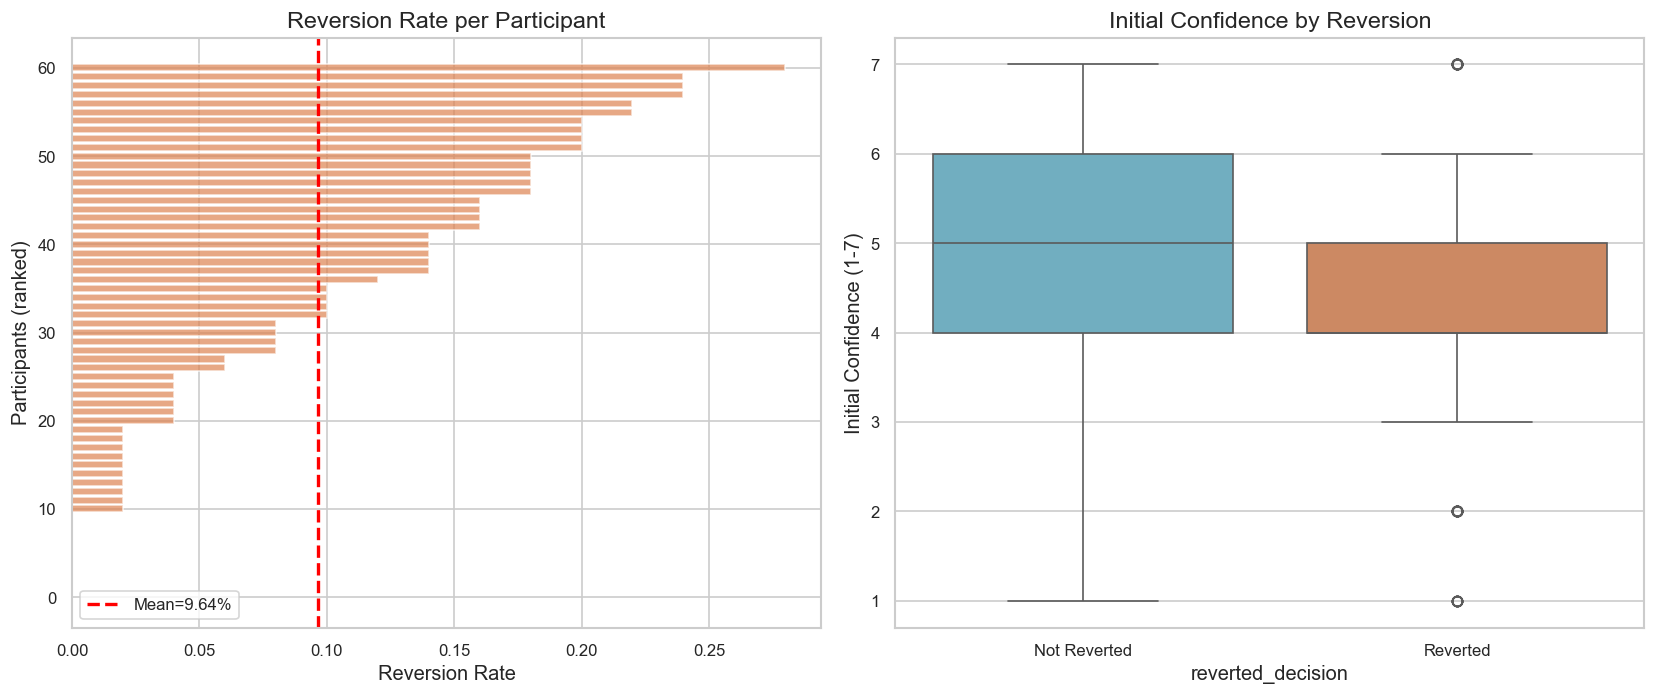

In [14]:
# Visualization: reversion patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Reversion rate per participant
rev_rate = ai_with_rev.groupby('participant_id')['reverted_decision'].mean().sort_values()
axes[0].barh(range(len(rev_rate)), rev_rate.values, color=COLORS['ai'], alpha=0.7)
axes[0].axvline(x=rev_rate.mean(), color='red', linewidth=2, linestyle='--',
              label=f'Mean={rev_rate.mean():.2%}')
axes[0].set_title('Reversion Rate per Participant')
axes[0].set_xlabel('Reversion Rate')
axes[0].set_ylabel('Participants (ranked)')
axes[0].legend()

# Initial confidence when reverted vs not
sns.boxplot(data=ai_with_rev, x='reverted_decision', y='initial_confidence',
           ax=axes[1], palette=[COLORS['neutral'], COLORS['ai']])
axes[1].set_xticklabels(['Not Reverted', 'Reverted'])
axes[1].set_title('Initial Confidence by Reversion')
axes[1].set_ylabel('Initial Confidence (1-7)')

plt.tight_layout()
plt.show()

## Findings & Next Steps

**Summarize after running:**

1. Overall over-reliance vs skepticism balance
2. AI confidence effect: does higher AI confidence drive more agreement?
3. Calibration quality across conditions
4. Confidence shift patterns
5. Symptom category effects on interaction
6. Reversion patterns and their outcomes

**Next**: NB3 for temporal dynamics and fatigue analysis.